# MScFE 622 STOCHASTIC MODELING 
Group Work Project \# 2

## Step 1: Data Preparation and Exploration 

In [1]:
!pip install -qq hmmlearn 

In [2]:
# import libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings("ignore")

<table style="width:100%; border-collapse: collapse; margin: 20px 0; font-family: sans-serif; font-size: 14px; color: #333;">
    <thead>
        <tr style="background-color: #1f77b4; color: white; text-align: left;">
            <th style="padding: 12px; width: 20%;">Asset Ticker</th>
            <th style="padding: 12px; width: 25%;">Asset Class</th>
            <th style="padding: 12px; width: 55%;">Underlying Instrument</th>
        </tr>
    </thead>
    <tbody>
        <tr style="border-bottom: 1px solid #ddd;">
            <td style="padding: 12px;"><b>SPY</b></td>
            <td style="padding: 12px;">Equity</td>
            <td style="padding: 12px;">S&P 500 ETF Trust</td>
        </tr>
        <tr style="border-bottom: 1px solid #ddd; background-color: #f8f9fa;">
            <td style="padding: 12px;"><b>TLT</b></td>
            <td style="padding: 12px;">Fixed Income</td>
            <td style="padding: 12px;">20+ Year Treasury Bond ETF</td>
        </tr>
        <tr style="border-bottom: 1px solid #ddd;">
            <td style="padding: 12px;"><b>GLD</b></td>
            <td style="padding: 12px;">Commodities</td>
            <td style="padding: 12px;">Gold Shares</td>
        </tr>
        <tr style="border-bottom: 2px solid #1f77b4; background-color: #f8f9fa;">
            <td style="padding: 12px;"><b>^VIX</b></td>
            <td style="padding: 12px;">Volatility</td>
            <td style="padding: 12px;">CBOE Volatility Index</td>
        </tr>
    </tbody>
</table>

## Download data from Y\-Finance

In [3]:
tickers = ["SPY", "TLT", "GLD", "^VIX"]

# data = yf.download(
#     tickers,
#     start="2005-01-01",
#     auto_adjust=True
# )["Close"]

# Save the downloaded data to CSV so it can be read later
csv_path = "market_data_close.csv"
data.to_csv(csv_path, index=True)
data = pd.read_csv(csv_path, index_col=0, parse_dates=True)
print(f"Data saved to {csv_path}")


[*********************100%***********************]  4 of 4 completed
Data saved to market_data_close.csv


In [4]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5376 entries, 2005-01-03 to 2026-05-15
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GLD     5376 non-null   float64
 1   SPY     5376 non-null   float64
 2   TLT     5376 non-null   float64
 3   ^VIX    5376 non-null   float64
dtypes: float64(4)
memory usage: 210.0 KB


In [5]:
data = data.dropna()

## Compute returns

## ETF Log Returns

**Formula:**

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [6]:
returns = np.log(data[["SPY", "TLT", "GLD"]] /data[["SPY", "TLT", "GLD"]].shift(1))

## VIX Changes: VIX log returns\.

In [7]:
vix_ret = np.log(data["^VIX"] / data["^VIX"].shift(1))

In [8]:
df = returns.copy()

df["VIX_RET"] = vix_ret

df = df.dropna()

## EXPLORATORY DATA ANALYSIS

In [9]:
stats = pd.DataFrame({
    "Mean": df.mean(),
    "Std": df.std(),
    "Skew": df.skew(),
    "Kurtosis": df.kurtosis()
})

stats

,Mean,Std,Skew,Kurtosis
SPY,0.000410,0.011962,-0.303845,14.714239
TLT,0.000118,0.009198,0.004477,3.435314
GLD,0.000423,0.011449,-0.454486,6.860337
VIX_RET,0.000050,0.075655,1.028670,6.511645


In [10]:
from matplotlib.gridspec import GridSpec
from matplotlib.dates import YearLocator, DateFormatter
from scipy.stats import norm

def generate_market_analysis(df, cols, window_short=21, window_long=252, z_thresh=2.0):
    plt.style.use("seaborn-v0_8-darkgrid")
    
    if isinstance(cols, str):
        cols = [cols]
        
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    if len(cols) > 1:
        fig = plt.figure(constrained_layout=True, figsize=(16, 10))
        gs = GridSpec(3, len(cols), figure=fig)
        
        ax_ts = fig.add_subplot(gs[0, :])
        palette = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:red"]
        colors = {col: palette[i % len(palette)] for i, col in enumerate(cols)}
        
        for col in cols:
            ax_ts.plot(df.index, df[col], label=f"{col} (daily)", color=colors[col], alpha=0.4, linewidth=0.8)
            roll_mean = df[col].rolling(window_short).mean()
            ax_ts.plot(df.index, roll_mean, label=f"{col} ({window_short}d mean)", color=colors[col], linewidth=1.6)
            
        roll_vol = (df[cols].rolling(window_short).std() * np.sqrt(252)).mean(axis=1)
        ax_vol = ax_ts.twinx()
        ax_vol.plot(df.index, roll_vol, color="crimson", linewidth=1.2, alpha=0.8, label=f"Avg {window_short}d Ann. Vol")
        ax_vol.set_ylabel("Annualized Volatility", color="crimson")
        ax_vol.tick_params(axis='y', labelcolor='crimson')
        
        ax_ts.set_title(f"ETF Daily Log Returns with {window_short}-day Smoother and Average Rolling Volatility")
        ax_ts.set_xlabel("Date")
        ax_ts.set_ylabel("Log Returns")
        handles_ts, labels_ts = ax_ts.get_legend_handles_labels()
        handles_vol, labels_vol = ax_vol.get_legend_handles_labels()
        ax_ts.legend(handles_ts + handles_vol, labels_ts + labels_vol, ncol=2, fontsize=9, loc='upper left')
        
        for i, col in enumerate(cols):
            ax = fig.add_subplot(gs[1, i])
            ax.plot(df.index, df[col], color=colors[col], alpha=0.5, linewidth=0.9)
            ax.plot(df.index, df[col].rolling(window_short).mean(), color=colors[col], linewidth=1.5)
            ax.set_title(f"{col} Daily Returns ({window_short}d mean)")
            ax.set_xlabel("Date")
            ax.set_ylabel("Log Return")
            
        for i, col in enumerate(cols):
            ax = fig.add_subplot(gs[2, i])
            sns.histplot(df[col].dropna(), bins=60, stat="density", alpha=0.4, color=colors[col], ax=ax)
            sns.kdeplot(df[col].dropna(), color=colors[col], linewidth=1.5, ax=ax)
            mu, sigma = df[col].mean(), df[col].std()
            x = np.linspace(mu - 5*sigma, mu + 5*sigma, 400)
            ax.plot(x, norm.pdf(x, mu, sigma), color='black', linestyle='--', linewidth=1.2, label='Normal fit')
            ax.set_title(f"{col} Return Distribution")
            ax.set_xlabel("Log Return")
            ax.set_ylabel("Density")
            ax.legend(fontsize=8)
            
    else:
        col = cols[0]
        vix = df[col].dropna().copy()
        
        roll_mean_s = vix.rolling(window_short).mean()
        roll_std_s = vix.rolling(window_short).std()
        roll_mean_l = vix.rolling(window_long).mean()
        roll_std_l = vix.rolling(window_long).std()
        
        z_s = (vix - roll_mean_s) / roll_std_s
        
        fig = plt.figure(constrained_layout=True, figsize=(16, 9))
        gs = GridSpec(2, 3, figure=fig, height_ratios=[2.0, 1.2])
        
        ax_ts = fig.add_subplot(gs[0, :])
        ax_ts.plot(vix.index, vix.values, color="tab:purple", alpha=0.45, linewidth=0.8, label=f"{col} (daily)")
        ax_ts.plot(roll_mean_s.index, roll_mean_s.values, color="tab:orange", linewidth=1.4, label=f"{window_short}d mean")
        ax_ts.plot(roll_mean_l.index, roll_mean_l.values, color="tab:blue", linewidth=1.4, label=f"{window_long}d mean")
        
        upper_band = roll_mean_s + 2 * roll_std_s
        lower_band = roll_mean_s - 2 * roll_std_s
        ax_ts.fill_between(vix.index, lower_band, upper_band, color="tab:orange", alpha=0.12, label=f"{window_short}d ±2σ band")
        
        extreme_hi = z_s > z_thresh
        extreme_lo = z_s < -z_thresh
        for mask, color in [(extreme_hi, (0.8, 0.1, 0.1, 0.12)), (extreme_lo, (0.1, 0.1, 0.8, 0.12))]:
            if mask.any():
                edges = np.flatnonzero(np.diff(np.r_[0, mask.astype(int), 0]))
                starts, ends = edges[::2], edges[1::2]
                for s, e in zip(starts, ends):
                    ax_ts.axvspan(vix.index[s], vix.index[e-1], color=color, lw=0)
                    
        ax_ts.set_title(f"{col} Daily Log Returns with Rolling Context and Extreme Regimes")
        ax_ts.set_xlabel("Date")
        ax_ts.set_ylabel("Log return")
        ax_ts.legend(ncol=3, fontsize=9, loc="upper left")
        ax_ts.axhline(0, color="black", linewidth=0.8, alpha=0.4)
        ax_ts.xaxis.set_major_locator(YearLocator(base=2))
        ax_ts.xaxis.set_major_formatter(DateFormatter('%Y'))
        
        ax_z = fig.add_subplot(gs[1, 0])
        ax_z.plot(z_s.index, z_s.values, color="tab:gray", linewidth=0.9)
        ax_z.axhline(z_thresh, color="crimson", linestyle="--", linewidth=1.0, label=f"z = {z_thresh:.0f}")
        ax_z.axhline(-z_thresh, color="royalblue", linestyle="--", linewidth=1.0, label=f"z = {-z_thresh:.0f}")
        ax_z.axhline(0, color="black", linewidth=0.8, alpha=0.4)
        ax_z.set_title(f"Short-term z-score of {col}")
        ax_z.set_xlabel("Date")
        ax_z.set_ylabel("z-score")
        ax_z.legend(fontsize=8, loc="upper left")
        ax_z.xaxis.set_major_locator(YearLocator(base=4))
        ax_z.xaxis.set_major_formatter(DateFormatter('%Y'))
        
        ax_dist = fig.add_subplot(gs[1, 1])
        sns.histplot(vix, bins=80, stat="density", color="tab:purple", alpha=0.35, ax=ax_dist)
        sns.kdeplot(vix, color="tab:purple", linewidth=1.6, ax=ax_dist, label="KDE")
        mu, sd = vix.mean(), vix.std()
        x = np.linspace(mu - 5*sd, mu + 5*sd, 500)
        ax_dist.plot(x, norm.pdf(x, mu, sd), color="black", linestyle="--", linewidth=1.2, label="Normal fit")
        ax_dist.set_title(f"{col} Distribution")
        ax_dist.set_xlabel("Log return")
        ax_dist.set_ylabel("Density")
        ax_dist.legend(fontsize=8)
        
        ax_tail = fig.add_subplot(gs[1, 2])
        thr = np.array([1.0, 1.5, 2.0, 2.5, 3.0]) * sd
        emp_right = [(vix > t).mean() for t in thr]
        emp_left  = [(vix < -t).mean() for t in thr]
        ax_tail.plot(thr/sd, emp_right, marker='o', color='crimson', label='P(R > t) empirical')
        ax_tail.plot(thr/sd, emp_left, marker='o', color='royalblue', label='P(R < -t) empirical')
        norm_right = [1 - norm.cdf(t/sd) for t in thr]
        norm_left  = [norm.cdf(-t/sd) for t in thr]
        ax_tail.plot(thr/sd, norm_right, linestyle='--', color='crimson', alpha=0.7, label='Normal ref (right)')
        ax_tail.plot(thr/sd, norm_left, linestyle='--', color='royalblue', alpha=0.7, label='Normal ref (left)')
        ax_tail.set_yscale('log')
        ax_tail.set_xlabel('Threshold (|t| in σ)')
        ax_tail.set_ylabel('Tail probability (log scale)')
        ax_tail.set_title('Tail Probabilities')
        ax_tail.legend(fontsize=8)

    plt.show()

## PLOT ETF Returns

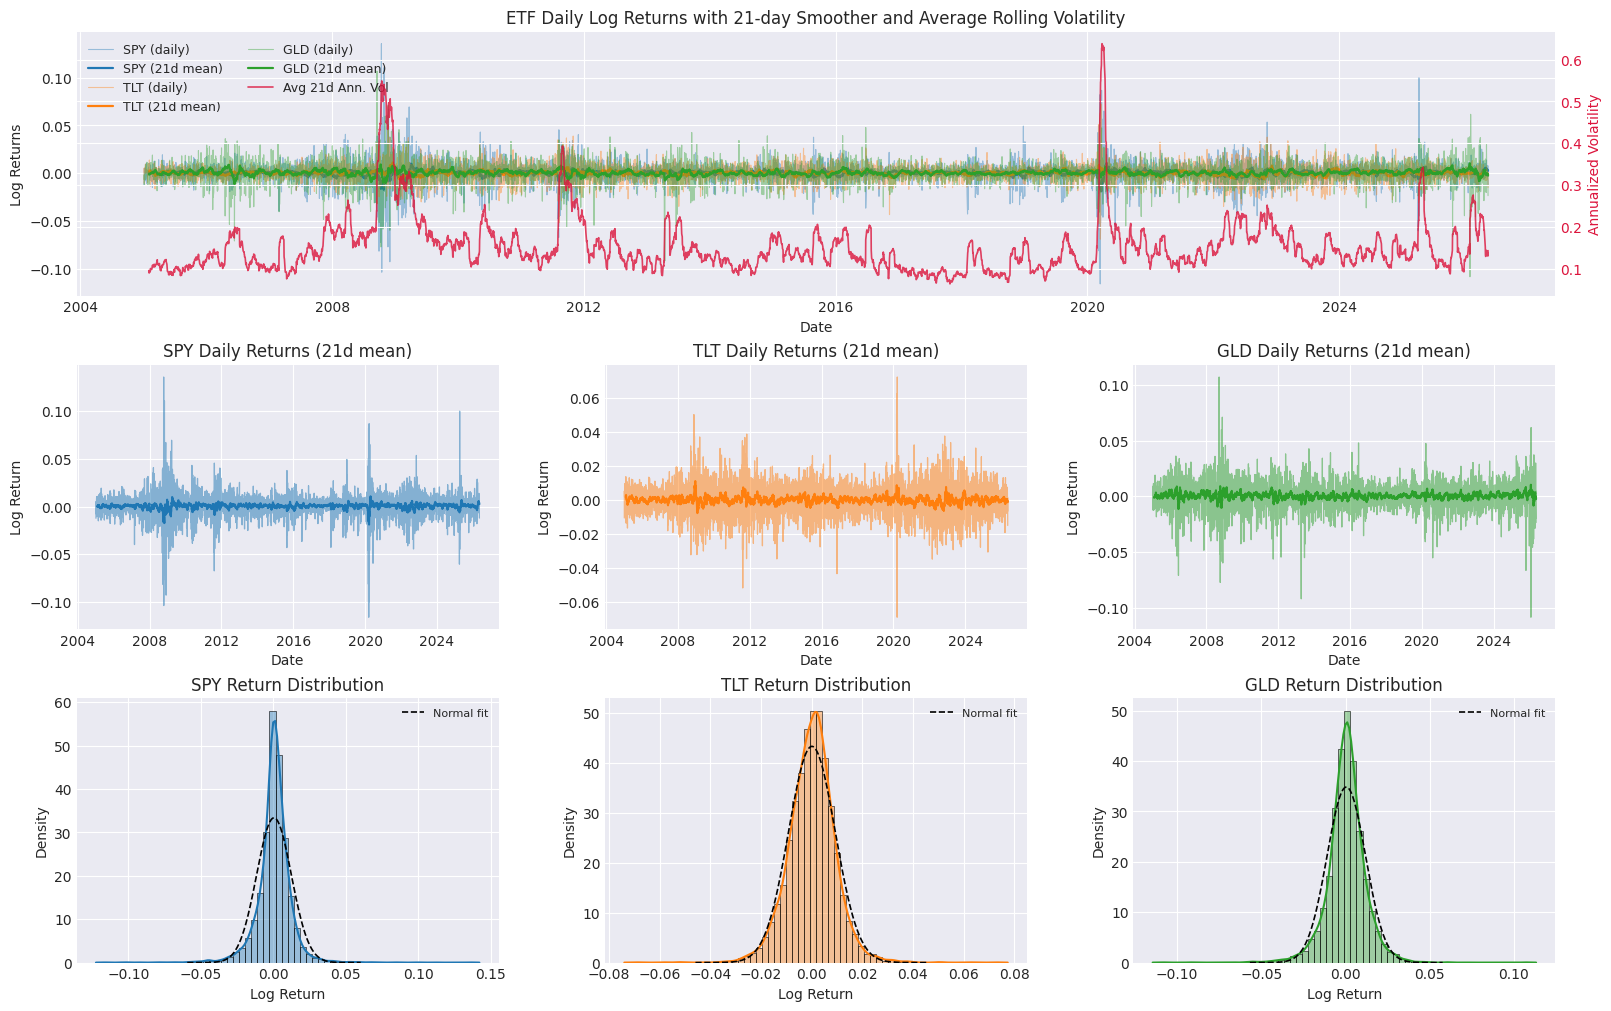

In [11]:
generate_market_analysis(df, cols=["SPY", "TLT", "GLD"])

## PLOT VIX Returns

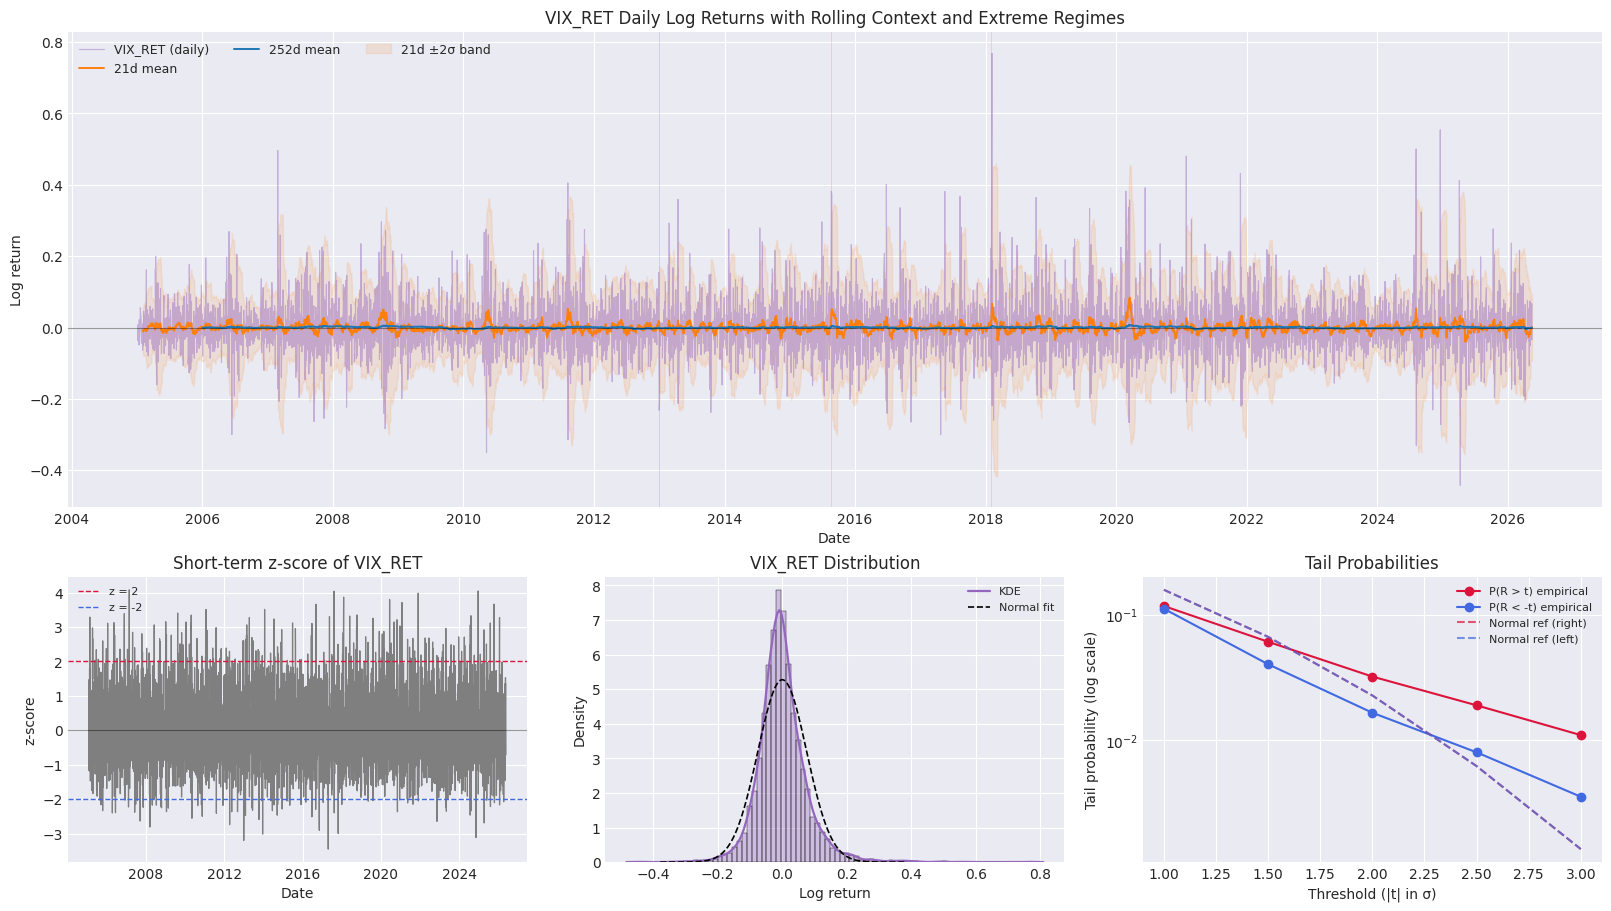

In [12]:
generate_market_analysis(df, cols="VIX_RET")

## CORRELATION HEATMAP

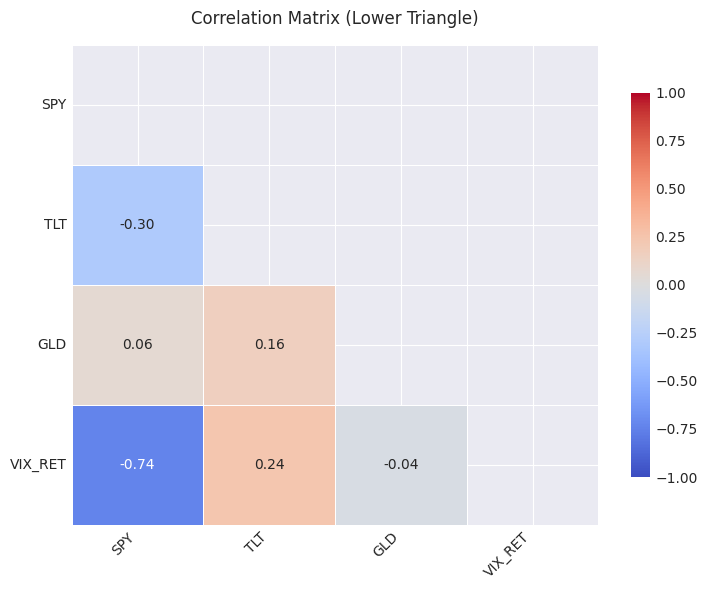

In [13]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7.5, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation Matrix (Lower Triangle)", fontsize=12, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# DISCRETE MARKOV CHAIN

## 3\-state example

In [14]:
q1 = df["VIX_RET"].quantile(0.33)
q2 = df["VIX_RET"].quantile(0.66)

## ASSIGN STATES

In [15]:
def classify_state(x):

    if x < q1:
        return 0   # low vol

    elif x < q2:
        return 1   # medium vol

    else:
        return 2   # high vol

df["MC_STATE"] = df["VIX_RET"].apply(classify_state)

states = [0,1,2]

transition_matrix = pd.DataFrame(
    index=states,
    columns=states
)

for i in states:

    current = df["MC_STATE"][:-1] == i

    for j in states:

        next_state = df["MC_STATE"][1:].values == j

        transition_matrix.loc[i,j] = (
            next_state[current].mean()
        )

transition_matrix

,0,1,2
0,0.323563,0.325817,0.35062
1,0.271856,0.36943,0.358714
2,0.392994,0.295019,0.311987


## VISUALIZE TRANSITION MATRIX

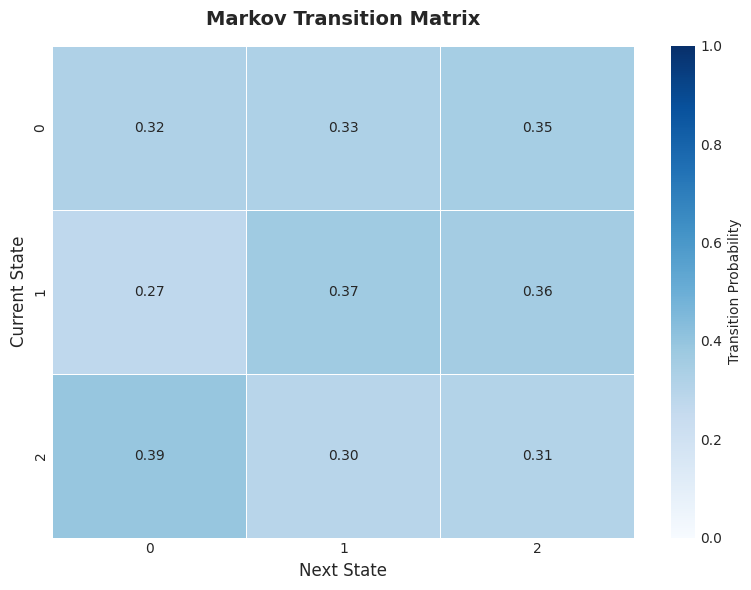

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    transition_matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={'label': 'Transition Probability'}
)

plt.title("Markov Transition Matrix", pad=15, fontsize=14, fontweight='bold')
plt.ylabel("Current State", fontsize=12)
plt.xlabel("Next State", fontsize=12)

plt.tight_layout()
plt.show()

## STATIONARY DISTRIBUTION

In [50]:
P = transition_matrix.to_numpy(dtype=float)

eigvals, eigvecs = np.linalg.eig(P.T)

# Find the index where the eigenvalue is closest to 1.0 using absolute differences
idx_idx = np.argmin(np.abs(eigvals - 1.0))

# Extract the corresponding eigenvector and drop any residual imaginary parts
stationary = eigvecs[:, idx_idx].real

# Normalize to sum to 1
stationary /= stationary.sum()

# Structure the output
stationary_dist = pd.Series(
    stationary, 
    index=transition_matrix.index, 
    name="Stationary_Probability"
)

stationary_dist

0    0.330131
1    0.329722
2    0.340148
Name: Stationary_Probability, dtype: float64

# HIDDEN MARKOV MODEL

In [17]:
X = df["VIX_RET"].values.reshape(-1,1)

## FIT 2\-STATE HMM

In [18]:
hmm_2 = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm_2.fit(X)

GaussianHMM(covariance_type='full', n_components=2, n_iter=1000,
            random_state=42)

## PREDICT STATES

In [19]:
states_2 = hmm_2.predict(X)

df["HMM_2_STATE"] = states_2

## FIT 3\-STATE HMM

In [20]:
hmm_3 = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm_3.fit(X)

states_3 = hmm_3.predict(X)

df["HMM_3_STATE"] = states_3

## VISUALIZE REGIMES

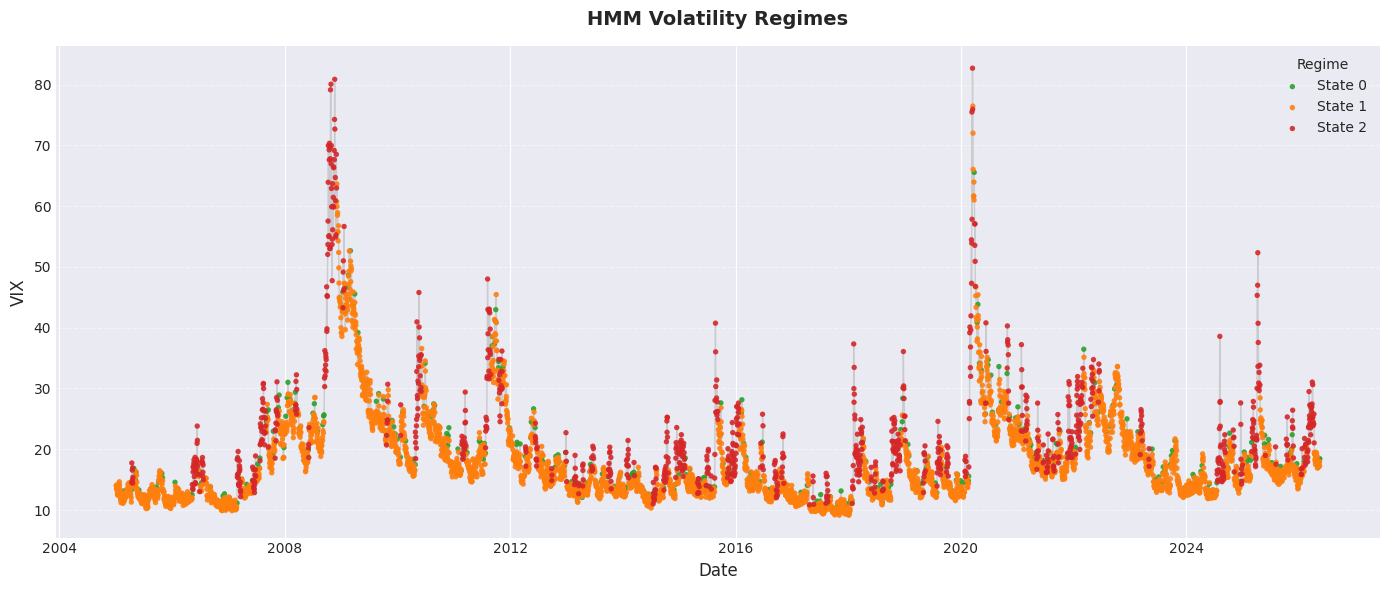

In [21]:
plt.figure(figsize=(14, 6))

vix_series = data["^VIX"].loc[df.index]
plt.plot(df.index, vix_series, color='gray', alpha=0.3, linewidth=1, zorder=1)

colors = ['#2ca02c', '#ff7f0e', '#d62728'] 

for state in range(3):
    mask = df["HMM_3_STATE"] == state
    plt.scatter(
        df.index[mask],
        vix_series[mask],
        label=f"State {state}",
        s=15,
        color=colors[state],
        alpha=0.9,
        edgecolors='none',
        zorder=2
    )

plt.title("HMM Volatility Regimes", pad=15, fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("VIX", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Regime")
plt.tight_layout()

plt.show()

# MODEL COMPARISON

## 1\. LOG LIKELIHOOD

In [22]:
loglik_2 = hmm_2.score(X)
loglik_3 = hmm_3.score(X)

## 2\. AIC/BIC FUNCTIONS

In [23]:
def compute_aic(loglik, k):

    return -2*loglik + 2*k


def compute_bic(loglik, k, n):

    return -2*loglik + k*np.log(n)

In [24]:
k2 = 2**2 + 2*2
k3 = 3**2 + 3*2

## COMPARISON TABLE

In [25]:
comparison = pd.DataFrame(
    {
        "Log-Likelihood": [loglik_2, loglik_3],
        "AIC": [compute_aic(loglik_2, k2), compute_aic(loglik_3, k3)],
        "BIC": [
            compute_bic(loglik_2, k2, len(X)),
            compute_bic(loglik_3, k3, len(X)),
        ],
    },
    index=["HMM-2", "HMM-3"],
)

comparison.index.name = "Model"
comparison = comparison.round(2)

comparison

,Log-Likelihood,AIC,BIC
Model,,,
HMM-2,6879.58,-13743.16,-13690.44
HMM-3,6941.35,-13852.70,-13753.86


# REGIME INTERPRETATION

## COMPUTE STATE CONDITIONAL RETURNS

In [26]:
state_returns = df.groupby(
    "HMM_3_STATE"
)[["SPY","TLT","GLD"]].mean()

state_returns

,SPY,TLT,GLD
HMM_3_STATE,,,
0,-0.010822,0.003320,-0.000655
1,0.002311,-0.000422,0.000604
2,-0.001952,0.000784,0.000202


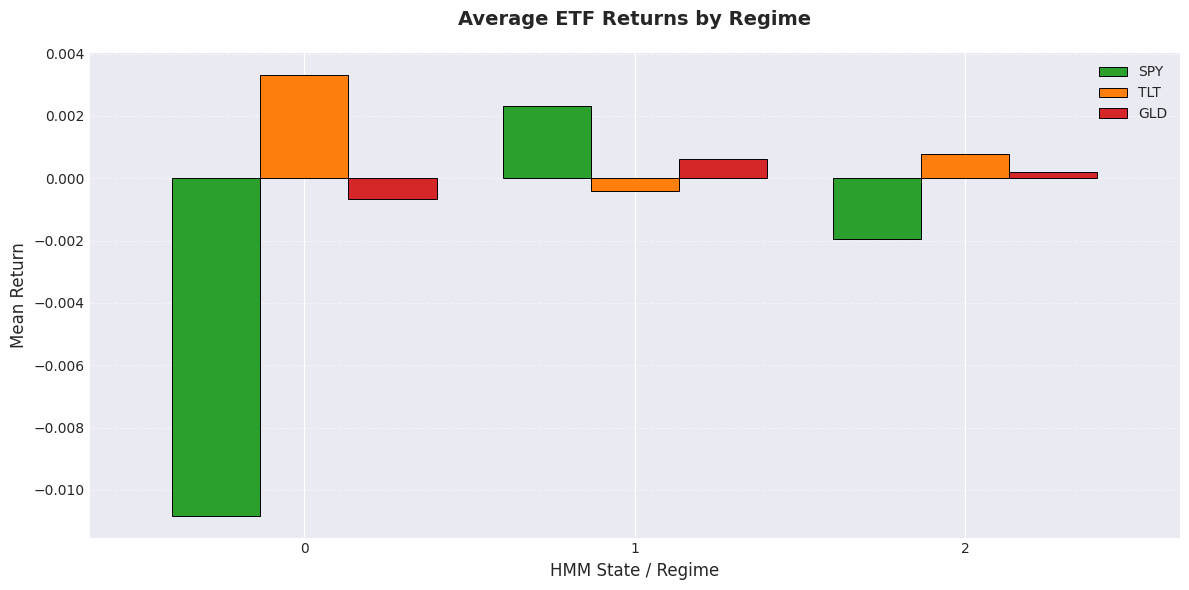

In [27]:
colors = ["#2ca02c", "#ff7f0e", "#d62728"]

ax = state_returns.plot(
    kind="bar", 
    figsize=(12, 6), 
    color=colors, 
    width=0.8,
    edgecolor="black",
    linewidth=0.7
)

plt.title("Average ETF Returns by Regime", pad=20, fontsize=14, fontweight="bold")
plt.xlabel("HMM State / Regime", fontsize=12)
plt.ylabel("Mean Return", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

# BUILD STRATEGY

## BEST ETF PER STATE

In [28]:
best_asset = state_returns.idxmax(axis=1)

best_asset

HMM_3_STATE
0    TLT
1    SPY
2    TLT
dtype: object

## CREATE ALLOCATION RULES

In [29]:
weights = pd.DataFrame(
    0,
    index=df.index,
    columns=["SPY","TLT","GLD"]
)

## APPLY RULES

In [30]:
for state in state_returns.index:

    asset = best_asset[state]

    mask = df["HMM_3_STATE"] == state

    weights.loc[mask, asset] = 1

## APPLY 1\-DAY LAG

In [31]:
weights = weights.shift(1)

# BACKTEST

$$R_{t}^{\text{strategy}} = \sum_{i=1}^{N} w_{i, t-1} R_{i, t}$$

## STRATEGY RETURNS

In [32]:
strategy_returns = (
    weights * df[["SPY","TLT","GLD"]]
).sum(axis=1)

# BENCHMARKS

## 1\. Equal Weights

In [33]:
equal_weight = (
    df[["SPY","TLT","GLD"]]
    .mean(axis=1)
)

## 2\. SPY Buy\-and\-Hold

In [34]:
spy_bh = df["SPY"]

## PERFORMANCE METRICS

In [35]:
def performance_metrics(r):

    cumulative = np.exp(r.cumsum())[-1] - 1

    ann_return = r.mean() * 252

    ann_vol = r.std() * np.sqrt(252)

    sharpe = ann_return / ann_vol

    wealth = np.exp(r.cumsum())

    peak = wealth.cummax()

    drawdown = (wealth - peak)/peak

    max_dd = drawdown.min()

    return pd.Series({
        "Cumulative Return": cumulative,
        "Annual Return": ann_return,
        "Volatility": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    })

In [36]:
results = pd.DataFrame({

    "Strategy":
    performance_metrics(strategy_returns),

    "Equal Weight":
    performance_metrics(equal_weight),

    "SPY":
    performance_metrics(spy_bh)

})

results

,Strategy,Equal Weight,SPY
Cumulative Return,50.140524,4.496014,8.082526
Annual Return,0.184468,0.079891,0.103442
Volatility,0.150477,0.097879,0.189889
Sharpe,1.225882,0.816224,0.544749
Max Drawdown,-0.259938,-0.234550,-0.551894


## EQUITY CURVES

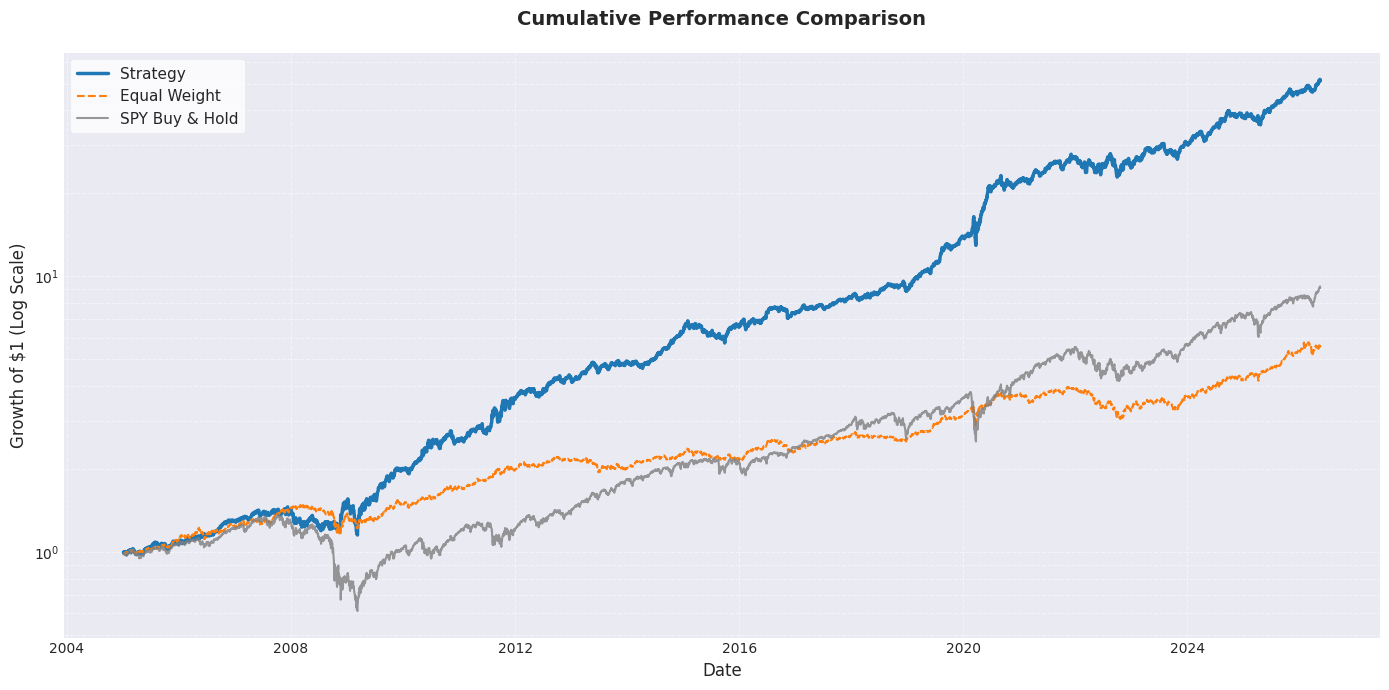

In [37]:
plt.figure(figsize=(14, 7))

# Plot performance curves with varied line weights and styles
plt.plot(np.exp(strategy_returns.cumsum()), label="Strategy", linewidth=2.5, color="#1f77b4")
plt.plot(np.exp(equal_weight.cumsum()), label="Equal Weight", linewidth=1.5, color="#ff7f0e", linestyle="--")
plt.plot(np.exp(spy_bh.cumsum()), label="SPY Buy & Hold", linewidth=1.5, color="#7f7f7f", alpha=0.8)

plt.title("Cumulative Performance Comparison", pad=20, fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Growth of $1 (Log Scale)", fontsize=12)

# Use log scale for long-term compound returns
plt.yscale("log")

# Clean formatting for grid and legend
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none", fontsize=11)

plt.tight_layout()
plt.show()

## SENSITIVITY ANALYSIS

## 1\. 2\-STATE vs 3\-STATE HMM COMPARISON

In [38]:
hmm_results = []

for n_states in [2, 3]:

    # Fit model
    hmm_model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )

    hmm_model.fit(X)

    # Predict regimes
    hidden_states = hmm_model.predict(X)

    df[f"HMM_{n_states}_STATE"] = hidden_states

    # Log-likelihood
    loglik = hmm_model.score(X)

    # Approximate parameter count
    k = n_states**2 + 2*n_states

    # AIC/BIC
    aic = -2 * loglik + 2 * k
    bic = -2 * loglik + k * np.log(len(X))

    # State conditional returns
    state_returns = df.groupby(
        f"HMM_{n_states}_STATE"
    )[["SPY", "TLT", "GLD"]].mean()

    # Best asset per state
    best_asset = state_returns.idxmax(axis=1)

    # Create weights
    weights = pd.DataFrame(
        0,
        index=df.index,
        columns=["SPY", "TLT", "GLD"]
    )

    for state in state_returns.index:

        asset = best_asset[state]

        mask = df[f"HMM_{n_states}_STATE"] == state

        weights.loc[mask, asset] = 1

    # Apply 1-day lag
    weights = weights.shift(1)

    # Strategy returns
    strategy_returns = (
        weights * df[["SPY", "TLT", "GLD"]]
    ).sum(axis=1)

    # Performance metrics
    cumulative = np.exp(strategy_returns.cumsum())[-1] - 1

    ann_return = strategy_returns.mean() * 252

    ann_vol = strategy_returns.std() * np.sqrt(252)

    sharpe = ann_return / ann_vol

    wealth = np.exp(strategy_returns.cumsum())

    peak = wealth.cummax()

    drawdown = (wealth - peak) / peak

    max_dd = drawdown.min()

    # Store results
    hmm_results.append({

        "States": n_states,

        "LogLik": loglik,

        "AIC": aic,

        "BIC": bic,

        "Annual Return": ann_return,

        "Volatility": ann_vol,

        "Sharpe": sharpe,

        "Max Drawdown": max_dd
    })

# Final comparison table
hmm_comparison = pd.DataFrame(hmm_results)

hmm_comparison

,States,LogLik,AIC,BIC,Annual Return,Volatility,Sharpe,Max Drawdown
0,2,6879.578270,-13743.156539,-13690.440428,0.207808,0.152552,1.362209,-0.304230
1,3,6941.350753,-13852.701507,-13753.858799,0.184468,0.150477,1.225882,-0.259938


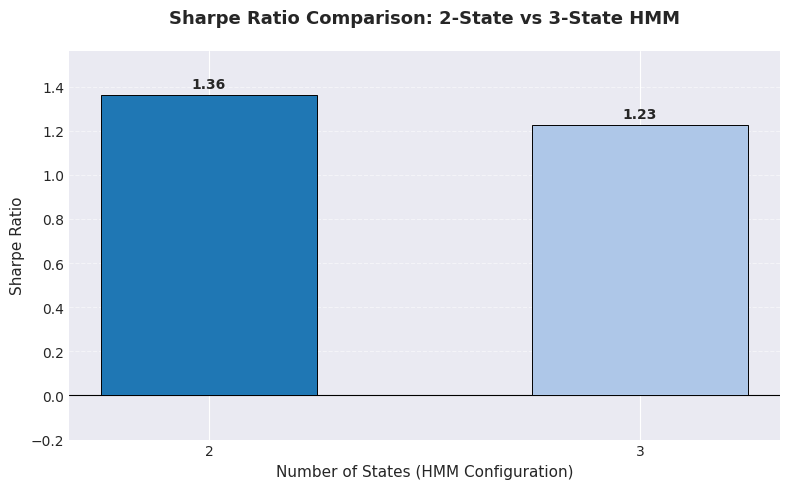

In [39]:
plt.figure(figsize=(8, 5))

colors = ["#1f77b4", "#aec7e8"]

bars = plt.bar(
    hmm_comparison["States"].astype(str),
    hmm_comparison["Sharpe"],
    color=colors,
    width=0.5,
    edgecolor="black",
    linewidth=0.7,
    zorder=3
)

plt.title("Sharpe Ratio Comparison: 2-State vs 3-State HMM", pad=20, fontsize=13, fontweight="bold")
plt.xlabel("Number of States (HMM Configuration)", fontsize=11)
plt.ylabel("Sharpe Ratio", fontsize=11)

# Add a horizontal baseline at 0
plt.axhline(0, color="black", linewidth=0.8, zorder=2)

# Value annotations on top of each bar
for bar in bars:
    height = bar.get_height()
    va_dir = "bottom" if height >= 0 else "top"
    xy_text = (0, 3) if height >= 0 else (0, -12)
    
    plt.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=xy_text,
        textcoords="offset points",
        ha="center",
        va=va_dir,
        fontsize=10,
        fontweight="bold"
    )

y_min, y_max = hmm_comparison["Sharpe"].min(), hmm_comparison["Sharpe"].max()
plt.ylim(min(0, y_min) - 0.2, max(0, y_max) + 0.2)

plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

Next, we prepare a concise comparison between the already fitted 2\-state and 3\-state Gaussian HMMs using the existing variables hmm\_2, hmm\_3, and X\. We compute log\-likelihood, AIC, BIC, and identify the preferred model by AIC and BIC without refitting\.

In [54]:
# Compute log-likelihoods using existing fitted models and data X
loglik_2_new = hmm_2.score(X)
loglik_3_new = hmm_3.score(X)

# Parameter count approximation consistent with earlier usage: k = n_states**2 + 2*n_states
k2_new = 2**2 + 2*2
k3_new = 3**2 + 2*3

# Compute AIC and BIC
AIC_2 = -2 * loglik_2_new + 2 * k2_new
AIC_3 = -2 * loglik_3_new + 2 * k3_new
BIC_2 = -2 * loglik_2_new + k2_new * np.log(len(X))
BIC_3 = -2 * loglik_3_new + k3_new * np.log(len(X))

# Determine preferred model by AIC and BIC (lower is better)
if (AIC_2 < AIC_3) and (BIC_2 < BIC_3):
    overall_pref = "HMM-2 (AIC, BIC)"
elif (AIC_3 < AIC_2) and (BIC_3 < BIC_2):
    overall_pref = "HMM-3 (AIC, BIC)"
elif (AIC_2 < AIC_3) and (BIC_3 < BIC_2):
    overall_pref = "HMM-2 (AIC), HMM-3 (BIC)"
elif (AIC_3 < AIC_2) and (BIC_2 < BIC_3):
    overall_pref = "HMM-3 (AIC), HMM-2 (BIC)"
else:
    overall_pref = "Mixed/Close"

# Assemble DataFrame
hmm_fit_cmp = pd.DataFrame({
    "LogLik": [loglik_2_new, loglik_3_new],
    "AIC": [AIC_2, AIC_3],
    "BIC": [BIC_2, BIC_3],
    "Preferred_by": [
        ("AIC" if AIC_2 < AIC_3 else "") + (", BIC" if BIC_2 < BIC_3 else ""),
        ("AIC" if AIC_3 < AIC_2 else "") + (", BIC" if BIC_3 < BIC_2 else "")
    ]
}, index=["HMM-2", "HMM-3"]).round(2)

print("HMM Fit Comparison")
hmm_fit_cmp

# Interpretation in 2-3 sentences
if "AIC" in hmm_fit_cmp.loc["HMM-3", "Preferred_by"] and "BIC" in hmm_fit_cmp.loc["HMM-3", "Preferred_by"]:
    interp = "Both AIC and BIC select the 3-state HMM, indicating that the improvement in fit outweighs the added complexity."
elif "AIC" in hmm_fit_cmp.loc["HMM-2", "Preferred_by"] and "BIC" in hmm_fit_cmp.loc["HMM-2", "Preferred_by"]:
    interp = "Both AIC and BIC select the 2-state HMM, suggesting the simpler model provides sufficient fit relative to its parsimony."
else:
    interp = "AIC and BIC disagree, reflecting a trade-off between goodness-of-fit and model complexity."

interp2 = "Lower AIC/BIC values indicate a better balance of fit and parsimony, whereas higher log-likelihood indicates better raw fit."
print(interp)
print(interp2)

HMM Fit Comparison
Both AIC and BIC select the 3-state HMM, indicating that the improvement in fit outweighs the added complexity.
Lower AIC/BIC values indicate a better balance of fit and parsimony, whereas higher log-likelihood indicates better raw fit.


## 2\. DIFFERENT QUANTILE THRESHOLDS

In [40]:
quantile_results = []

quantile_sets = [

    (0.33, 0.66),
    (0.25, 0.75),
    (0.20, 0.80)

]

for q_low, q_high in quantile_sets:

    # Create thresholds
    q1 = df["VIX_RET"].quantile(q_low)
    q2 = df["VIX_RET"].quantile(q_high)

    # State classification
    def classify_state(x):

        if x < q1:
            return 0

        elif x < q2:
            return 1

        else:
            return 2

    df["MC_STATE"] = df["VIX_RET"].apply(classify_state)

    # State conditional returns
    state_returns = df.groupby(
        "MC_STATE"
    )[["SPY", "TLT", "GLD"]].mean()

    # Best asset
    best_asset = state_returns.idxmax(axis=1)

    # Build weights
    weights = pd.DataFrame(
        0,
        index=df.index,
        columns=["SPY", "TLT", "GLD"]
    )

    for state in state_returns.index:

        asset = best_asset[state]

        mask = df["MC_STATE"] == state

        weights.loc[mask, asset] = 1

    # Lagged implementation
    weights = weights.shift(1)

    # Strategy returns
    strategy_returns = (
        weights * df[["SPY", "TLT", "GLD"]]
    ).sum(axis=1)

    # Metrics
    ann_return = strategy_returns.mean() * 252

    ann_vol = strategy_returns.std() * np.sqrt(252)

    sharpe = ann_return / ann_vol

    quantile_results.append({

        "Quantiles": f"{q_low:.2f}-{q_high:.2f}",

        "Annual Return": ann_return,

        "Volatility": ann_vol,

        "Sharpe": sharpe
    })

# Results table
quantile_comparison = pd.DataFrame(quantile_results)

quantile_comparison

,Quantiles,Annual Return,Volatility,Sharpe
0,0.33-0.66,0.019921,0.169102,0.117802
1,0.25-0.75,0.037477,0.170343,0.220006
2,0.20-0.80,0.037846,0.173265,0.218429


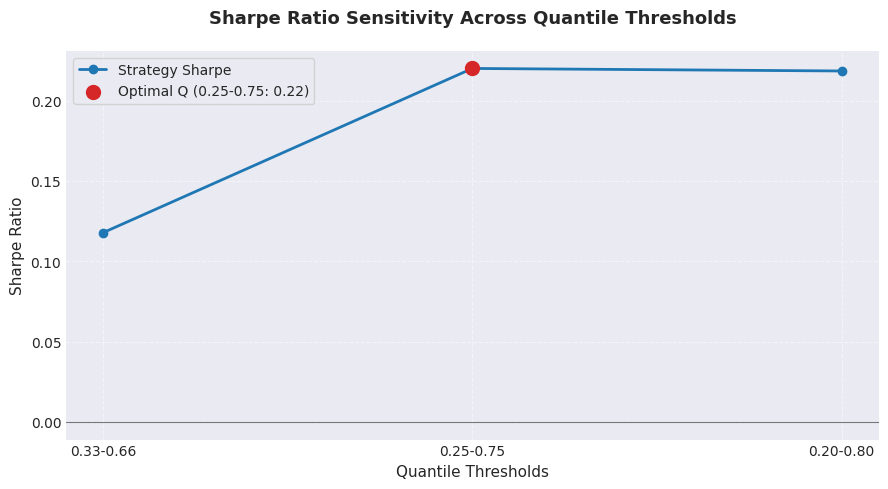

In [41]:
plt.figure(figsize=(9, 5))

plt.plot(
    quantile_comparison["Quantiles"],
    quantile_comparison["Sharpe"],
    marker="o",
    markersize=6,
    linewidth=2,
    color="#1f77b4",
    label="Strategy Sharpe"
)

plt.title("Sharpe Ratio Sensitivity Across Quantile Thresholds", pad=20, fontsize=13, fontweight="bold")
plt.xlabel("Quantile Thresholds", fontsize=11)
plt.ylabel("Sharpe Ratio", fontsize=11)

# Highlight the optimal quantile selection
idx_max = quantile_comparison["Sharpe"].idxmax()
opt_q = quantile_comparison["Quantiles"].loc[idx_max]
opt_s = quantile_comparison["Sharpe"].loc[idx_max]

plt.scatter(opt_q, opt_s, color="#d62728", s=100, zorder=5, label=f"Optimal Q ({opt_q}: {opt_s:.2f})")
plt.axhline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.5)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best", frameon=True)
plt.tight_layout()

plt.show()

## 3\. ROLLING SAMPLE PERIODS

In [42]:
rolling_results = []

window_size = 252 * 5   # 5 years

for start in range(0, len(df) - window_size, 252):

    end = start + window_size

    sample = df.iloc[start:end].copy()

    X_sample = sample["VIX_RET"].values.reshape(-1,1)

    # Fit HMM
    hmm_model = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )

    hmm_model.fit(X_sample)

    # Predict states
    sample["STATE"] = hmm_model.predict(X_sample)

    # State conditional returns
    state_returns = sample.groupby(
        "STATE"
    )[["SPY", "TLT", "GLD"]].mean()

    # Best asset
    best_asset = state_returns.idxmax(axis=1)

    # Create weights
    weights = pd.DataFrame(
        0,
        index=sample.index,
        columns=["SPY", "TLT", "GLD"]
    )

    for state in state_returns.index:

        asset = best_asset[state]

        mask = sample["STATE"] == state

        weights.loc[mask, asset] = 1

    # 1-day lag
    weights = weights.shift(1)

    # Strategy returns
    strategy_returns = (
        weights * sample[["SPY", "TLT", "GLD"]]
    ).sum(axis=1)

    # Metrics
    ann_return = strategy_returns.mean() * 252

    ann_vol = strategy_returns.std() * np.sqrt(252)

    sharpe = ann_return / ann_vol

    rolling_results.append({

        "Start": sample.index[0],

        "End": sample.index[-1],

        "Annual Return": ann_return,

        "Volatility": ann_vol,

        "Sharpe": sharpe
    })

# Results
rolling_comparison = pd.DataFrame(rolling_results)

rolling_comparison

,Start,End,Annual Return,Volatility,Sharpe
0,2005-01-04,2010-01-05,0.026130,0.234809,0.111280
1,2006-01-04,2011-01-04,0.108442,0.171642,0.631793
2,2007-01-05,2012-01-04,-0.140928,0.239846,-0.587577
3,2008-01-07,2013-01-07,-0.093331,0.251333,-0.371345
4,2009-01-06,2014-01-07,0.090535,0.174573,0.518606
5,2010-01-06,2015-01-07,0.208967,0.145600,1.435218
6,2011-01-05,2016-01-07,-0.013629,0.149957,-0.090886
7,2012-01-05,2017-01-06,-0.019796,0.126029,-0.157075
8,2013-01-08,2018-01-08,-0.006143,0.116086,-0.052917
9,2014-01-08,2019-01-09,0.167009,0.104921,1.591751


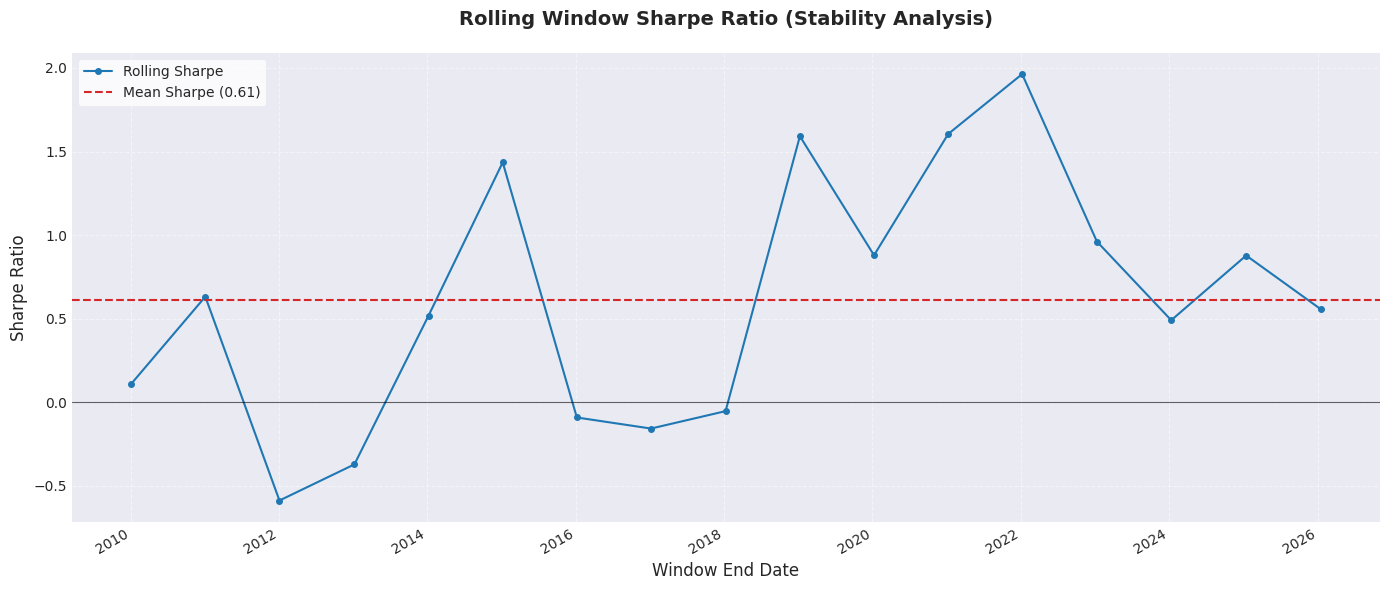

In [43]:
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_comparison["End"],
    rolling_comparison["Sharpe"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    color="#1f77b4",
    label="Rolling Sharpe"
)

# Highlight overall mean and the zero-line threshold
mean_sharpe = rolling_comparison["Sharpe"].mean()
plt.axhline(mean_sharpe, color="#d62728", linestyle="--", linewidth=1.5, label=f"Mean Sharpe ({mean_sharpe:.2f})")
plt.axhline(0, color="black", linewidth=0.8, alpha=0.6)

plt.title("Rolling Window Sharpe Ratio (Stability Analysis)", pad=20, fontsize=14, fontweight="bold")
plt.xlabel("Window End Date", fontsize=12)
plt.ylabel("Sharpe Ratio", fontsize=12)

# Clean up date axis layout and grid depth
plt.gcf().autofmt_xdate()
plt.grid(True, linestyle="--", alpha=0.5, zorder=0)
plt.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()

## 

## 

### 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=2472d9c7-c221-45eb-9e8a-37f9e2d7e94b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>